# Using Madina to Generate Accessibility Metrics
## Installing Madina

* You must install the Madina package, instructions are here: https://madinadocs.readthedocs.io/en/latest/installation_guide.html

## Data Preparation
* Make sure ALL DATA FILES are in the same projection. We suggest using `EPSG:26986` NAD83 / Massachusetts Mainland in Meters.
* The units of your projection is the unit of all parameters used. 
* All data files must be placed in a folder `Cities/Cambridge/Data`, this folder must be in the same folder where your script is.
* you can use a different city name other than `Cambridge`. For instance, the folder `Cities/Cambridge_intervention/Data` can hold the data for an intervention scenario.


### Network
* Be sure to use a connected network for cambridge, you can use the one provided in Canvas
* Canvas > Modules > Class 4 > `Basefile_2025.3dm`
* In Rhino, select all curves on the  `OSM_sidewalks` layer
* Export the layer `OSM_sidewalks` to geojson
* From the Rhino file UNA Toolbar > Export
* When prompted `Select object for  export`, right click on the `2010TigerRoad_Cambridge1000m`, Click `Select Objects`, Then press `Enter`.
* Make sure to pick these settings when exporting:
    * Formart=geojson
    * ExportType=File
    * Points=include
    * Curves=Include
    * Results=include
    * Attributes=Include
    * Type=Include
    * Coordinates=Include
    * EPSG=26986
* Save as `network.geojson` in the folder `Cities/Cambridge/Data`
### Origins

* The workflow measures accessibility for one origin layer, to multiple types of destinations.
* If you want to measure access from multiple origins, create a pairing table for each origin separatly. 
* We use the layer `buildings` from the same Rhino file `Basefile_2025.3dm`
* Export as geojson using the UNA Toolbar with the same export settings for the network
* Save as `buildings.geojson` in the folder `Cities/Cambridge/Data`

### Destinations

* We will use the NAICS code establishment data as destinations.
* See all the geojson files of different kinds of business establishments we have copied to the folder `Cities/Cambridge/Data`


## Pairing Table preparation

* Instructions on how to prepare the pairing tables are here: https://madinadocs.readthedocs.io/en/latest/ped_access.html
* Create your pairing table to include your selected settings and parameters. 
* Save it as `pairing.csv` inside the folder `Cities/Cambridge/Data`

## Running the UNA accessibility workflow

* After installing the Madina package, and placing your data and pairing table in the folder `Cities/Cambridge/Data`, you can run the following code:

In [ ]:
# Download the package needed in terminal
# pip install plotly
# conda install -c conda-forge nbformat>=4.2.0
# conda install -c conda-forge python-kaleido

In [ ]:
from madina.una.workflows import KNN_accessibility
import geopandas as gdf
import pandas as pd

In [ ]:

# Initialize and run the accessibility analysis workflow with specified parameters
KNN_accessibility(
   city_name="Cambridge",        # Name of target city for analysis
   pairings_file="pairing.csv",  # Path to CSV file containing origin-destination pairs
   num_cores=8,                 # Number of CPU cores to use for parallel processing
)

In [10]:
# KNN Access for Schools
# load all the school file, and concat into one file, save as one geojson file
list_of_schools = ['daycare', 'privateschool', 'publicschool', 'youthcenter']
filefolder = 'processed/'
# file paths are filefolder + list_of_schools[i] + '.geojson'
for file in list_of_schools:
    filepath = filefolder + file + '.geojson'
    #load file
    df = gdf.read_file(filepath)
    # if there is no df_full, assign df to df_full
    if 'df_full' not in locals():
        df_full = df
    # else, concat df to df_full
    else:
        df_full = gdf.GeoDataFrame(pd.concat([df_full, df], ignore_index=True))
df_full.to_file('Cities/Cambridge/Data/schools.geojson', driver='GeoJSON')
df_full.head()

,id,__GUID,category,_to_subway_reach_sr800,_to_subway_g_sr800,_to_bluebike_reach_sr800,_to_bluebike_g_sr800,_to_bus_reach_sr800,_to_bus_g_sr800,geometry
0,0,13b9dd40-84a3-4a37-bbf4-d6622165124b,daycare,0.0,0.000000,2.0,1.173284,4.0,2.014044,POINT (232911 900859)
1,1,105b02b6-c214-447f-8333-300a85136475,daycare,0.0,0.000000,1.0,0.862093,12.0,8.035640,POINT (230323 905435)
2,2,abfd4afe-9e17-4a80-86c8-7708b7c2ddd9,daycare,0.0,0.000000,6.0,3.235085,24.0,14.064804,POINT (233752 902106)
3,3,774f7eda-8c8b-4e1d-8fba-083b162b1942,daycare,1.0,0.477456,5.0,3.030235,45.0,27.209307,POINT (232581 902302)
4,4,4789cc96-8152-4f88-bd05-446c64884e71,daycare,0.0,0.000000,3.0,2.250062,36.0,22.647331,POINT (233174 902594)


# School KNN Analysis

In [33]:
# load the pairing file
pairing = pd.read_csv('Cities/Cambridge/Data/pairing_schools.csv')
# change the origin file and origin name
pairing['Origin_File'] = 'schools.geojson'
pairing['Origin_Name'] = 'schools'
pairing.head()
# save the pairing file
pairing.to_csv('Cities/Cambridge/Data/pairing_schools.csv', index=False)


In [36]:
KNN_accessibility(
   city_name="Cambridge",        # Name of target city for analysis
   pairings_file="pairing_schools.csv",  # Path to CSV file containing origin-destination pairs
   num_cores=8,                 # Number of CPU cores to use for parallel processing
)

total time | seconds elapsed |                flow_name                 | event
    0.0000 |        0.000000 |                   ---                    | SIMULATION STARTED: VERSION: 0.0.15, RELEASE DATEL 2023-02-16
    0.0089 |        0.008900 |                   ---                    | 3.12.8 | packaged by conda-forge | (main, Dec  5 2024, 14:25:12) [Clang 18.1.8 ]
    0.0106 |        0.001669 |                   ---                    | Dependencies: Geopandas:1.0.1, Shapely:2.0.7, Pandas:2.2.2, Numpy:2.2.2, NetworkX:3.4.2
    1.1556 |        1.144989 |          (1/3) Schools_to_Train          | network FIle Loaded, Projection: EPSG:6491
    3.2650 |        2.109486 |          (1/3) Schools_to_Train          | network topology created
    3.2809 |        0.015856 |          (1/3) Schools_to_Train          | schools file schools.geojson Loaded, Projection: EPSG:6491
    3.2857 |        0.004781 |          (1/3) Schools_to_Train          | Subway file transp_subway.geojson Loaded, Pr

/Users/beckyxu/opt/anaconda3/envs/madina_env/lib/python3.12/site-packages/pyogrio/raw.py:198: RuntimeWarning: Several features with id = 0 have been found. Altering it to be unique. This warning will not be emitted anymore for this layer
  return ogr_read(


    3.6413 |        0.333844 |          (1/3) Schools_to_Train          | NetworkX Graphs Created.
    6.4466 |        2.805306 |          (1/3) Schools_to_Train          | accissibility calculated.
    6.4616 |        0.014977 |           (2/3) Schools_to_Bus           | Bus file transp_bus.geojson Loaded, Projection: EPSG:6491
    6.4848 |        0.023146 |           (2/3) Schools_to_Bus           | Origins and Destinations Inserted.
    6.7935 |        0.308754 |           (2/3) Schools_to_Bus           | NetworkX Graphs Created.
    9.4117 |        2.618153 |           (2/3) Schools_to_Bus           | accissibility calculated.
    9.4225 |        0.010826 |        (3/3) Schools_to_Bluebike         | Bluebike file transp_bluebike.geojson Loaded, Projection: EPSG:6491
    9.4428 |        0.020323 |        (3/3) Schools_to_Bluebike         | Origins and Destinations Inserted.
    9.7360 |        0.293159 |        (3/3) Schools_to_Bluebike         | NetworkX Graphs Created.
   12.2767 

# constructing new pairing table

In [ ]:
# # create a dictionary to store destination file name, destination name, and destination weight
# destination_dict = {}
# destination_dict['Destination_File'] = ['daycare.geojson', 'privateschool.geojson', 'publicschool.geojson']
# destination_dict['Destination_Name'] = ['daycare', 'privateschool', 'publicschool']
# destination_dict['Destination_Weight'] = ['Count', 'Count', 'Count']
# # add a new entry with file, name, weight to destination_dict
# new_entry = {'Destination_File': 'youthcenter.geojson', 'Destination_Name': 'youthcenter', 'Destination_Weight': 'Count'}
# # concat and entry
# pairing = pd.concat([pairing, pd.DataFrame(new_entry, index=[0])], ignore_index=True)
# pairing.head()

{'Destination_File': ['daycare.geojson',
  'privateschool.geojson',
  'publicschool.geojson'],
 'Destination_Name': ['daycare', 'privateschool', 'publicschool'],
 'Destination_Weight': ['Count', 'Count', 'Count']}

------

## Looking at the output
Once the code is finished running, a folder named `Cities\Cambridge\KNN_workflow`. A time stamped folder there will contain three files:

* `origin_record.geoJSON`: This is a copy of the origin file used, in this case, a copy of the `buildings.geojson` that contains: 
    * all the original columns and geometry in `buildings.geojson`
    * three additional columns per destination, for example: `Buildings_to_Grocery_reach`, `Buildings_to_Grocery_gravity`, `Buildings_to_Grocery_knn_access`.
    * Two summary columns:
        * `total_knn_access`, which, for each building, sums up the total KNN access scores from this buildings to all destinations
        * `normalized_knn_access` is a normalized copy of `total_knn_access` with values between zero and one; where one means the highest KNN total buildings, and 0 means the lowerst KNN total buildings
* `origin_record.csv`: a CSV copy of `origin_record.geoJSON` that doesn't contain geometry. 
* `time_log.csv`: a log file that keeps track of events and timing within the workflow.

In [ ]:
import geopandas as gpd

# Define the relative path to the GeoJSON file
gdf = gpd.read_file('Cities/Cambridge/KNN_workflow/2025-03-03 15-02/origin_record.csv')
gdf.drop(columns=['geometry'], inplace=True)
# List columns
list(gdf.columns)
gdf.head()

['id',
 '__GUID',
 'category',
 '_to_subway_reach_sr800',
 '_to_subway_g_sr800',
 '_to_bluebike_reach_sr800',
 '_to_bluebike_g_sr800',
 '_to_bus_reach_sr800',
 '_to_bus_g_sr800',
 'geometry',
 'Schools_to_Train_reach',
 'Schools_to_Train_gravity',
 'Schools_to_Train_knn_access',
 'Schools_to_Bus_reach',
 'Schools_to_Bus_gravity',
 'Schools_to_Bus_knn_access',
 'Schools_to_Bluebike_reach',
 'Schools_to_Bluebike_gravity',
 'Schools_to_Bluebike_knn_access',
 'total_knn_access',
 'normalized_knn_access']

In [118]:
df_sm = df_full[['geometry', '__GUID']]
df_sm = df_sm.merge(gdf, on='__GUID')

In [120]:
df_sm.head()
df_sm = df_sm.to_crs(epsg=3857)
# drop duplicated rows from df_sm
df_sm = df_sm.drop_duplicates()
len(df_sm)

260

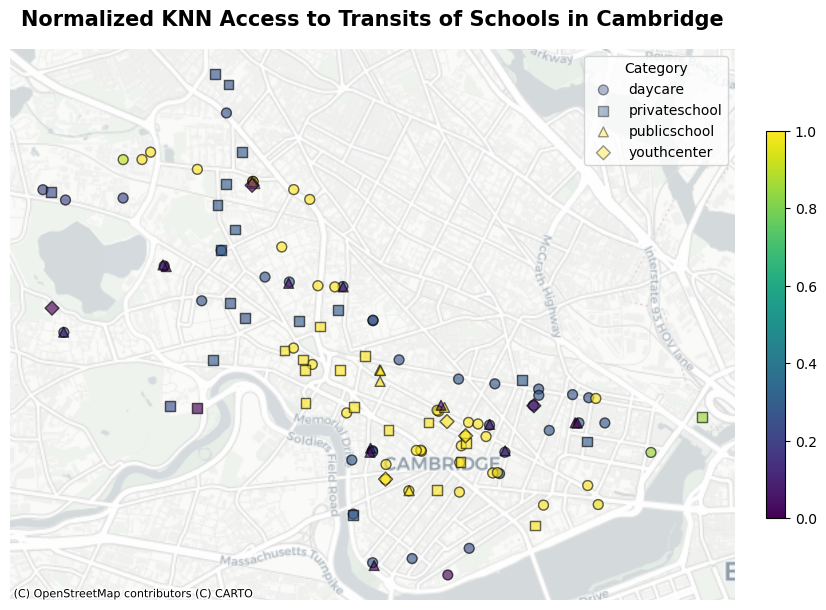

In [121]:
import matplotlib.pyplot as plt
import contextily as ctx
import matplotlib as mpl
# Ensure 'total_knn_access' is numeric
df_sm['normalized_knn_access'] = pd.to_numeric(df_sm['normalized_knn_access'])

fig, ax = plt.subplots(figsize=(10, 10))
categories = df_sm['category'].unique()
markers = ['o', 's', '^', 'D', 'P', '*', 'X', 'h', 'H', 'd', 'v', '<', '>', 'p', '8']

for category, marker in zip(categories, markers):
    df_category = df_sm[df_sm['category'] == category]
    df_category.plot(ax=ax, 
                     alpha=0.4,
                     column='normalized_knn_access',
                     cmap='viridis',
                     markersize=50,
                     marker=marker,
                     edgecolor='k',
                     label=category)
ax.axis('off')
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
plt.title("Normalized KNN Access to Transits of Schools in Cambridge", fontsize=15, fontweight='bold')
leg = plt.legend(title="Category", loc='upper right')

# Add color scale legend
sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=df_sm['normalized_knn_access'].min(), vmax=df_sm['normalized_knn_access'].max()))
sm._A = []
cbar = plt.colorbar(sm, ax=ax, orientation='vertical', fraction=0.025, pad=0.04)

plt.show()


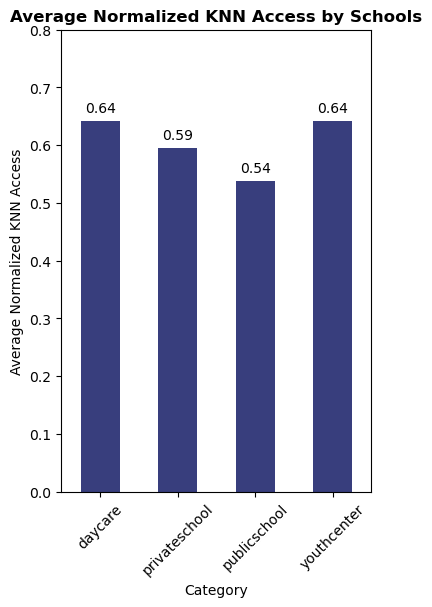

In [135]:
# Group by 'category' and calculate the mean of 'normalized_knn_access'
category_mean = df_sm.groupby('category')['normalized_knn_access'].mean()

# Plot the average normalized_knn_access by category
category_mean.plot(kind='bar', color='#383E7D', figsize=(4, 6))
plt.title("Average Normalized KNN Access by Schools", fontsize=12, fontweight='bold')
plt.ylim(0, 0.8)
plt.xlabel("Category")
plt.ylabel("Average Normalized KNN Access")
plt.xticks(rotation=45)
# Add data labels to the bars
for i, value in enumerate(category_mean):
    plt.text(i, value + 0.01, round(value, 2), ha='center', va='bottom')
plt.show()

## Visualizing output
* Generally, it might be easier to visualize spatial data in GIS, but some Python packages offer great visualization capabilities. 
    * Plotly Scatter Maps https://plotly.com/python/mapbox-layers/
    * PyDeck https://deckgl.readthedocs.io/en/latest/


In [ ]:
import plotly
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from shapely import Point

# ----------------------------
# Data Loading & Preprocessing
# ----------------------------

# Define the relative path to the restaurants GeoJSON file
restaurants_path = Path("Cities/Cambridge/Data/Restaurants_infogroup_NAICS.geoJSON")

# Load the file
restaurants = gpd.read_file(restaurants_path)


origin_record['lat'] = origin_record.to_crs("EPSG:4326").geometry.y
origin_record['long'] = origin_record.to_crs("EPSG:4326").geometry.x

restaurants['lat'] = restaurants.to_crs("EPSG:4326").geometry.y
restaurants['long'] = restaurants.to_crs("EPSG:4326").geometry.x

# Define zoom center point
zoomed_y, zoomed_x = 42.36557868815264, -71.10406106943056

# Create clipping mask for focused area visualization
clip_mask_gdf = gpd.GeoDataFrame(geometry=[Point(zoomed_x, zoomed_y)], crs = "EPSG:4326").to_crs(origin_record.crs).buffer(600, cap_style = 3)
clip_mask = clip_mask_gdf[0]


# ----------------------------
# Metric Calculations
# ----------------------------

reach_metric = 'Buildings_to_Restaurants_reach'
gravity_metric = "Buildings_to_Restaurants_gravity"

# Filter data for visualization
min_access_subway = gpd.clip(origin_record, clip_mask)
zero_access_subway = min_access_subway[min_access_subway[reach_metric] == 0] 
min_access_subway = min_access_subway[min_access_subway[reach_metric] > 0]

# Color scheme definitions
colors = ["rgb(53, 80, 112)", "rgb(109, 89, 122)", "rgb(181, 101, 118)", "rgb(229, 107, 111)", "rgb(234, 172, 139)"]

mini_access = gpd.clip(origin_record, clip_mask)


# ----------------------------
# Figure Initialization
# ----------------------------
# Create 2x2 subplot layout with custom sizing
fig = make_subplots(
    rows=2,
    cols=2,
    horizontal_spacing=0.07,
    vertical_spacing=0.01,
    column_widths=[0.5, 0.5],
    specs=[
        [{'type':'mapbox'}, {'type':'mapbox'}],
        [{'type':'mapbox', 'colspan': 2}, None], 
    ],
    insets=[{'cell':(2,1), 'l':1.15, 'w':0.90, 'b':0.05, 'h':0.90, 'type': 'mapbox'}]
    #subplot_titles=("First Subplot","Second Subplot", "Third Subplot", "FOurth Subplot")
)


# ----------------------------
# Subplot A: Reach Visualization
# ----------------------------
### Reach subplot

fig.add_trace(
    go.Scattermapbox(
        name="Reach Score",
        lat=list(min_access_subway['lat']),
        lon=list(min_access_subway['long']),
        mode='markers',
        marker=go.scattermapbox.Marker(
            size=4,
            color=list(min_access_subway[reach_metric]),
            colorscale="Turbo", #"Bluered", #RdBu",
            showscale=True,
            colorbar=dict(len=0.50, y=0.75, x=0.465), 
            cmax=min_access_subway[reach_metric].max(), 
            cmin=min_access_subway[gravity_metric].min(),
        ),
        showlegend=False,
        text=min_access_subway[reach_metric],
    ),
    row=1,
    col=1
)




fig.add_trace(
    go.Scattermapbox(
        name="Reach Score",
        lat=list(zero_access_subway['lat']),
        lon=list(zero_access_subway['long']),
        mode='markers',
        marker=go.scattermapbox.Marker(
            size=4,
            color='silver',
        ),
        showlegend=False,
    ),
    row=1,
    col=1
)


fig.add_trace(
    go.Scattermapbox(
        name="Restaurant",
        lat=list(restaurants['lat']),
        lon=list(restaurants['long']),
        mode='markers',
        marker=go.scattermapbox.Marker(
            size=8,
            color='red',
        ),
        legend='legend',
        text=restaurants["COMPANY"],
        showlegend=True,
    ),
    row=1,
    col=1
)


# ----------------------------
# Subplot B: Gravity Visualization
# ----------------------------
### gravity subplot

fig.add_trace(
    go.Scattermapbox(
        name="Gravity Score",
        lat=list(min_access_subway['lat']),
        lon=list(min_access_subway['long']),
        mode='markers',
        marker=go.scattermapbox.Marker(
            size=4,
            color=list(min_access_subway[gravity_metric]),
            colorscale="Turbo", #"Bluered", #RdBu",
            showscale=True,
            colorbar=dict(len=0.50, y=0.75, x=1.00), 
            cmax=min_access_subway[reach_metric].max(),
            cmin=min_access_subway[gravity_metric].min(),
        ),
        showlegend=False,
        text=min_access_subway[gravity_metric],
    ),
    row=1,
    col=2
)

fig.add_trace(
    go.Scattermapbox(
        name="Reach Score",
        lat=list(zero_access_subway['lat']),
        lon=list(zero_access_subway['long']),
        mode='markers',
        marker=go.scattermapbox.Marker(
            size=4,
            color='silver',
        ),
        showlegend=False,
    ),
    row=1,
    col=2
)


fig.add_trace(
    go.Scattermapbox(
        name="Restaurant",
        lat=list(restaurants['lat']),
        lon=list(restaurants['long']),
        mode='markers',
        marker=go.scattermapbox.Marker(
            size=8,
            color='red',
        ),
        legend='legend2',
        showlegend=True,
        text=restaurants["COMPANY"],
    ),
    row=1,
    col=2
)


# ----------------------------
# Subplot C: KNN Access Visualization
# ----------------------------

### KNN-Access subplot

knn_color_scale = [
    (0.0, "rgb(234, 172, 139)"),  (0.50, "rgb(234, 172, 139)"),
    (0.50, "rgb(229, 107, 111)"),  (0.80, "rgb(229, 107, 111)"),
    (0.80, "rgb(181, 101, 118)"),  (0.90, "rgb(181, 101, 118)"),
    (0.90, "rgb(109, 89, 122)"), (0.99, "rgb(109, 89, 122)"),
    (0.99, "rgb(53, 80, 112)"),   (1, "rgb(53, 80, 112)"),
]


fig.add_trace(
    go.Scattermapbox(
        name="KNN Accessz",
        lat=list(origin_record['lat']),
        lon=list(origin_record['long']),
        mode='markers',
        marker=go.scattermapbox.Marker(
            size=4,
            color=list(origin_record["normalized_knn_access"]),
            #colorscale="Bluered", #"Bluered", #RdBu",
            colorscale=knn_color_scale,
            showscale=True,
            colorbar=dict(len=0.50, y=0.25, x=1.00), 
        ),
        showlegend=False,
        text=origin_record["normalized_knn_access"],
    ),
    row=2,
    col=1
)


# zoom boundary 

small_boc_lat_lon = list(clip_mask_gdf.to_crs("EPSG:4326")[0].exterior.coords)

# ----------------------------
# Subplot D: Zoomed Inset Visualization
# ----------------------------

fig.add_trace(
    go.Scattermapbox(
        mode='lines',
        lat=[x[1] for x in small_boc_lat_lon],
        lon=[x[0] for x in small_boc_lat_lon],
        fill = "toself",
        #marker = { 'size': 10, 'color': "red" }
        line = {'color': 'black', 'width': 2},
        showlegend=False,
    ),

    row=2,
    col=1
)

### KNN-Access inset
fig.add_trace(
    go.Scattermapbox(
        name="KNN Accessz",
        lat=list(mini_access['lat']),
        lon=list(mini_access['long']),
        mode='markers',
        marker=go.scattermapbox.Marker(
            size=4,
            color=list(mini_access["normalized_knn_access"]),
            colorscale=knn_color_scale,
        ),
        subplot = 'mapbox4',
        showlegend=False,
        text=mini_access["normalized_knn_access"],
    ),
)

## Two Red frames and two ;ines for inset
zoom_x0, zoom_y0 = 0, 0


fig.add_shape(
    dict(
        type="rect",
        x0=0.535,
        x1=0.95,
        y0=0.025,
        y1=0.47,
        line_color="black",
        line_width=2,
        xref="paper",
        yref="paper",
    )
)




# ----------------------------
# Annotation & Layout Configuration
# ----------------------------
# Add panel labels (A, B, C, D)
fig.add_annotation(
    text="(A): Reach",
    xref="paper",
    yref="paper",
    x=0.01,
    y=0.99,
    bgcolor="white",
    font_size=20,
    showarrow=False,
    #opacity=0.8
)


fig.add_annotation(
    text="(B): Gravity",
    xref="paper",
    yref="paper",
    x=0.61,
    y=0.99,
    bgcolor="white",
    font_size=20,
    showarrow=False,
    #opacity=0.8
)


fig.add_annotation(
    text="(C) KNN Access - Citywide",
    xref="paper",
    yref="paper",
    x=0.01,
    y=0.47,
    bgcolor="white",
    font_size=20,
    showarrow=False,
    #opacity=0.8
)

fig.add_annotation(
    text="(D) KNN Access",
    xref="paper",
    yref="paper",
    x=0.63,
    y=0.45,
    bgcolor="white",
    font_size=20,
    showarrow=False,
    #opacity=0.8
)


# Mapbox configuration
mapbox_access_token='pk.eyJ1IjoiYXpoYXNzIiwiYSI6ImNrNmw5NG04eDA5ZHMzZW82bTYycWo4bmoifQ.oaiLbRe8I2CUClonWKeCGw'

fig.update_layout(
    #title='Accessibility from home locations to a basket of destinations',
    #title_text="Specs with Subplot Title"
    showlegend=True,
    width=1000, 
    height=1000,
    margin=dict(l=3, r=10, t=3, b=3),

    legend=dict(
        xref="paper",
        yref="paper",
        x=0.30,
        y=0.99, 
        bgcolor="white",
        bordercolor="Black",
        borderwidth=2
    ),

    legend2=dict(
        xref="paper",
        yref="paper",
        x=0.83,
        y=0.99, 
        title_font_family="Times New Roman",
        bgcolor="white",
        bordercolor="Black",
        borderwidth=2
    ),


    mapbox1=dict(
        style='carto-positron',
        zoom=14.40,
        center=dict(
            lat=zoomed_y,
            lon=zoomed_x
        )
    ),
    
    mapbox2=dict(
        accesstoken=mapbox_access_token,
        style='light', #'carto-positron',
        zoom=14.40,
        center=dict(
            lat=zoomed_y,
            lon=zoomed_x
        )
    ), 

    mapbox3=dict(
        accesstoken=mapbox_access_token,
        style='light', #'carto-positron',
        zoom=11.60,
        center=dict(
            lat=42.371332893636215,
            lon=-71.06816229527924
        )
    ),

    mapbox4=dict(
        accesstoken=mapbox_access_token,
        style='light', #'carto-positron',
        zoom=14.40,
        center=dict(
            lat=zoomed_y,
            lon=zoomed_x
        )
    ), 


)

# ----------------------------
# Output Generation
# ----------------------------
# Export visualizations
fig.write_html("access_map_3_panels.html")
fig.write_image("access_map_3_panels.png", scale=5)
fig.write_image("access_map_3_panels.pdf", scale=5)

#There seems to be a bug with plotly where multiple legends are not shown correctly. Disable legend before showing plot
fig.update_layout(showlegend=False)
fig.show()

/var/folders/_7/dnhg9j7d32z31mv539nxpcq40000gn/T/ipykernel_55408/3404675736.py:73: DeprecationWarning:

*scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/

/var/folders/_7/dnhg9j7d32z31mv539nxpcq40000gn/T/ipykernel_55408/3404675736.py:98: DeprecationWarning:

*scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/

/var/folders/_7/dnhg9j7d32z31mv539nxpcq40000gn/T/ipykernel_55408/3404675736.py:115: DeprecationWarning:

*scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/

/var/folders/_7/dnhg9j7d32z31mv539nxpcq40000gn/T/ipykernel_55408/3404675736.py:139: DeprecationWarning:

*scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/

/var/folders/_7/dnhg9j7d32z31mv539nxpcq40000gn/T/ipykernel_55408/3404675736.py:161: DeprecationWarning:

*